# 大模型调用学习（访问和运行过程）

## 大模型访问

In [44]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()


def predict(prompt, print_response = False):
    client = OpenAI(api_key=os.getenv("AIHUBMIX_API_KEY"),base_url=os.getenv("AIHUBMIX_BASE_URL"))
    messages = [{"role" : "user", "content" : prompt}]
    result = client.chat.completions.create(messages=messages, model=os.getenv("AIHUBMIX_MODEL"))
    if print_response : 
        print("下面是 : AI返回的json结果")
        print(result.model_dump_json(indent=2))
    return result.choices[0].message.content

In [45]:
predict("介绍自己", print_response = True)

下面是 : AI返回的json结果
{
  "id": "chatcmpl-DhXLFT6a6dqJe2zhx8By938h8CW2E",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": "你好！我是ChatGPT，一个由OpenAI开发的大型语言模型。我的主要功能是通过自然语言处理技术，理解并生成各种文本内容。我能帮助你解答问题、写作、翻译、编程、学习新知识，甚至陪你聊天。\n\n我有如下特点：\n\n1. **广泛的知识面**——截至2024年6月，我掌握了丰富的科学、技术、文化、历史等各领域知识。\n2. **多语言能力**——我能用中文、英文及其他多种语言交流。\n3. **持续学习**——虽然我的数据有截止日期，但我能结合现有知识内容，给出合理的解答和建议。\n4. **善于表达**——无论是简洁的回答，还是详细的分析，我都可以根据你的需求调整风格。\n\n你可以把我当作全天候的智能助理、学习伙伴或创作助手。如果你有任何需要，随时告诉我吧！",
        "refusal": null,
        "role": "assistant",
        "annotations": null,
        "audio": null,
        "function_call": null,
        "tool_calls": null
      }
    }
  ],
  "created": 1779268641,
  "model": "gpt-4.1-2025-04-14",
  "object": "chat.completion",
  "service_tier": "default",
  "system_fingerprint": "fp_dc49d4fcba",
  "usage": {
    "completion_tokens": 210,
    "prompt_tokens": 9,
    "total_tokens": 219,
    "completion_tokens_d

'你好！我是ChatGPT，一个由OpenAI开发的大型语言模型。我的主要功能是通过自然语言处理技术，理解并生成各种文本内容。我能帮助你解答问题、写作、翻译、编程、学习新知识，甚至陪你聊天。\n\n我有如下特点：\n\n1. **广泛的知识面**——截至2024年6月，我掌握了丰富的科学、技术、文化、历史等各领域知识。\n2. **多语言能力**——我能用中文、英文及其他多种语言交流。\n3. **持续学习**——虽然我的数据有截止日期，但我能结合现有知识内容，给出合理的解答和建议。\n4. **善于表达**——无论是简洁的回答，还是详细的分析，我都可以根据你的需求调整风格。\n\n你可以把我当作全天候的智能助理、学习伙伴或创作助手。如果你有任何需要，随时告诉我吧！'

上面是OpenAI接口的完整result，在聊天窗口中显示的推理结果只是取了result['choices'][0]['message']['content']。

client.chat.completions.create 方法本质是发送了下面这样的一个请求 ： 
```
!curl -s http://192.168.31.200:8000/v1/chat/completions \
    -H "Content-Type: application/json" \
    -d '{ \
        "model": "Qwen2-0.5B-Instruct",\
        "messages": [{"role": "user", "content": "详细介绍下你自己。"}],\
        "max_tokens": 512,\
        "temperature": 0.7  \
    }' | jq
```

# 模型后台运行

标准化提示语
序列化提示语
模型预测
反序列化为文本

In [46]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda:0"
model_path = "/data2/anti_fraud/models/modelscope/hub/Qwen/Qwen2-0___5B-Instruct"

In [47]:
import torch
from modelscope import snapshot_download
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "Qwen/Qwen2-0.5B-Instruct" # ModelScope 上的模型名字
cache_dir = r"../models" # 你希望模型下载到哪个大目录

# 使用snapshot下载模型
model_path = snapshot_download(
    model_id, 
    cache_dir=cache_dir
)

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16
).to(device)

tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    use_fast=False,
    trust_remote_code=True
)

2026-05-20 17:17:29,692 - modelscope - INFO - Creating symbolic link [../models\Qwen\Qwen2-0.5B-Instruct].
2026-05-20 17:17:29,695 - modelscope - WARNING - Failed to create symbolic link ../models\Qwen\Qwen2-0.5B-Instruct for e:\Code\StudyLLM\models\Qwen\Qwen2-0___5B-Instruct.


## 标准化提示语

下面这里的message是json格式，如果是调用API可以直接把这个message丢入进去

然后tokenizer.apply_chat_template 可以吧prompt 进行结构化，结构化后调用AI进行使用

In [48]:
prompt = "详细介绍下你自己。"
messages = [
    {"role" : "system", "content" : "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]

input_text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
print(input_text)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
详细介绍下你自己。<|im_end|>
<|im_start|>assistant



In [49]:
tokenizer.tokenize("congratulation")

['con', 'gr', 'at', 'ulation']

## 提示语序列化 

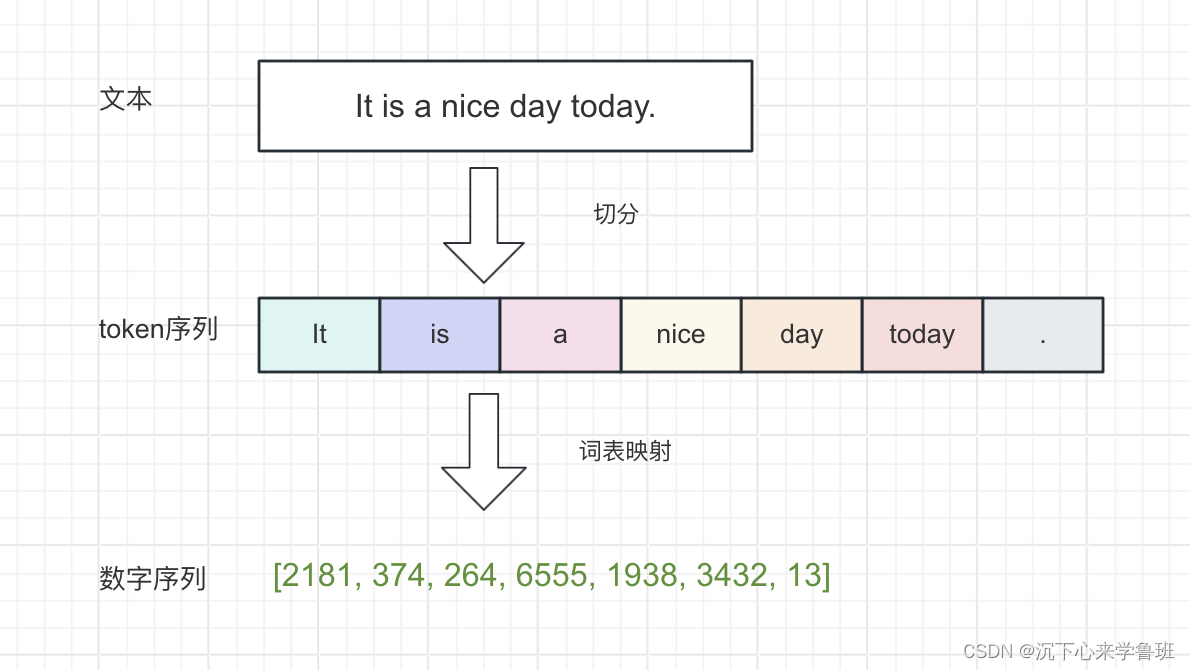

In [50]:
# return_tensors='pt'表示以pytorch张量的形式返回
model_inputs = tokenizer([input_text], return_tensors="pt").to(device)
print(f"{model_inputs}")

{'input_ids': tensor([[151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
         151645,    198, 151644,    872,    198, 113511,  16872, 107828,   1773,
         151645,    198, 151644,  77091,    198]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}


In [51]:
len(tokenizer.encoder) # 打印下词表大小

151643

## 模型预测生成

model.generate 函数用于对序列进行推理，然后输出预测的新序列

In [52]:
response_ids = model.generate(
    model_inptus.input_ids,
    max_new_tokens = 512
)

print(f"response_ids :{response_ids}")

response_ids :tensor([[151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
         151645,    198, 151644,    872,    198, 113511,  16872, 107828,   1773,
         151645,    198, 151644,  77091,    198, 100622, 101977,  48692, 100168,
           3837, 108763, 104934,   5373, 100708,  57191, 104049, 100708,   3837,
         101886, 101068, 110180, 100798,  57191, 101224,   1773,  35946, 110266,
          74220,   3837,  99250,  70500, 102688, 102104,  86119,  33108,  99553,
          27369,   1773, 109944, 100364,  20002,  78973,  27369,   5373,  28072,
          19564,  31338,  96422,   5373, 106185,  86119,   5373,  43959, 108704,
           5373, 108598,  46100,  49567,   1773, 151645]], device='cuda:0')


In [53]:
## 反序列化为文本
response_ids = [
    output_ids[len(input_ids) : ] for input_ids, output_ids in zip(model_inptus.input_ids, response_ids)
]

response_text = tokenizer.batch_decode(response_ids, skip_special_tokens=True)[0]
response_text

'作为一个人工智能，我没有情感、意识或自我意识，因此无法有自己的经历或感受。我只是一个程序，被设计用来回答问题和提供信息。我可以帮助用户搜索信息、提供建议、解答问题、生成文本、编写代码等。'

# model.generate运行过程

In [54]:
generate_ids = model_inputs.input_ids

In [57]:
# 这里具体的讲述了调用generate_ids 他的是一个结果，然后温度来选择下一个生成的词语
def generate_next_token(model, generate_ids, temperature = 0.7, debug = False):
    logits = model.forward(generate_ids).logits
    
    if temperature > 0:
        probs = torch.softmax(logits[:, -1] / temperature, dim = -1)
        next_token = torch.multinomial(probs[-1], num_samples=1)  # 按照概率随机选取下一个token
    else:
        next_token = torch.argmax(logits[:, -1], dim=-1)
    print("next_id: ", next_token, ", token: ", tokenizer.decode(next_token)) if debug else None
    return next_token.reshape(-1, 1)

In [ ]:
# 这里是自回归解码 ： 用预测出来的结果来预测下次的结果

next_token = generate_next_token(model, generate_ids, debug=True)
generate_ids = torch.cat((generate_ids, next_token), dim=1) # 这里是把预测出来的结果重新进行拼接回去，用于下次预测
# tokenizer 解码出来
tokenizer.batch_decode(generate_ids[:, len(model_inputs.input_ids[0]):], skip_special_tokens=True)[0] 

next_id:  tensor([15469], device='cuda:0') , token:  AI


'作为一个AI'

In [59]:
tokenizer

Qwen2Tokenizer(name_or_path='../models\Qwen\Qwen2-0___5B-Instruct', vocab_size=151643, model_max_length=32768, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>']}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [61]:
import time
max_new_tokens = 128
end_token_id = 151645
generate_ids = model_inputs.input_ids

for _ in range(max_new_tokens):
    next_token = generate_next_token(model, generate_ids, debug=False)
    generate_ids = torch.cat((generate_ids, next_token), dim=1)
    if next_token.item() == end_token_id:
        break
    print(tokenizer.decode(next_token[0], skip_special_tokens=False), end='')

我是一个人工智能语言模型，我被设计为帮助用户回答问题、提供信息、完成任务等。我能够理解自然语言和语音，能够进行语言生成，能够回答问题、提��建议、完成任务。

# 主体内部

In [63]:
print(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm()
        (post_attention_layernorm): Qwen2RMSNorm()
      )
    )
    (norm): Qwen2RMSNorm()
  )
  (lm_head): Linear(in_featur